<a href="https://colab.research.google.com/github/sahdahx/Komstat-II/blob/main/KomstatII_W4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Komputasi Statistika II | 10th Mar 2026

## Regresi Linear

- Model statistik yang umum dan paling sederhana yang digunakan untuk Machine Learning untuk melakukan prediksi dengan cara supervised learning.
- Regresi Linier melibatkan 2 variabel dimana salah satunya adalah variabel independen (x) dan satu lagi adalah variabel dependen (y).
- Tinggi badan merupakan variabel independen (x), dan berat badan merupakan variabel dependen (y).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.DataFrame([[151,63],[174,81],[138,56],[186,91],[128,47], [136,57],[179,76],[163,72],[152,62],[131,48]])
df.columns = ['x','y']

x_train = df['x'].values[:,np.newaxis]
y_train = df['y'].values

lm = LinearRegression()
lm.fit(x_train,y_train) #fase training
print('Coefficient : ' + str(lm.coef_))
print('Intercept : ' + str(lm.intercept_))

x_test = [[170],[171]] #data yang akan diprediksi

p = lm.predict(x_test) #fase prediksi
print(p) #hasil prediksi

Coefficient : [0.67461045]
Intercept : -38.45508707607701
[76.22868928 76.90329973]


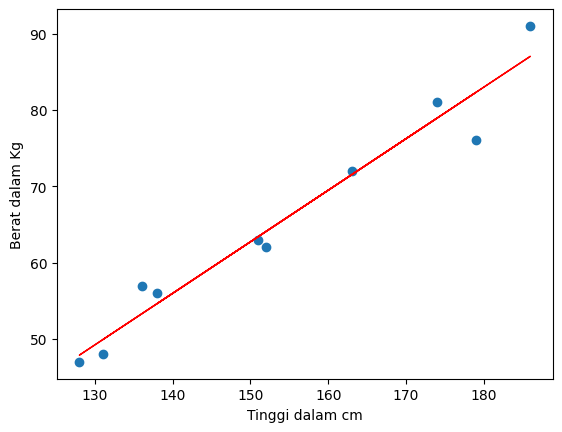

In [ ]:
# prepare plot
pb = lm.predict(x_train)
dfc = pd.DataFrame({'x': df['x'],'y':pb})
plt.scatter(df['x'],df['y'])
plt.plot(dfc['x'],dfc['y'],color='red',linewidth=1)
plt.xlabel('Tinggi dalam cm')
plt.ylabel('Berat dalam Kg')
plt.show()

## Regresi Polinomial

*Polynomial regression* (regresi polinomial) adalah teknik pemodelan statistik atau machine learning yang digunakan untuk memprediksi nilai kontinu, di mana hubungan antara variabel independen (x) dan variabel dependen (y) dimodelkan sebagai fungsi polinomial (melengkung) derajat ke-n.

Polynomial regression adalah ekstensi dari regresi linear yang memungkinkan model mempelajari hubungan non-linear antara variabel prediktor (x) dan respons (y).

**Contoh:**

Di bawah adalah data 18 mobil saat melewati suatu gerbang tol tercatat kecepatan mobil, dan waktu (jam) lewatnya terjadi.

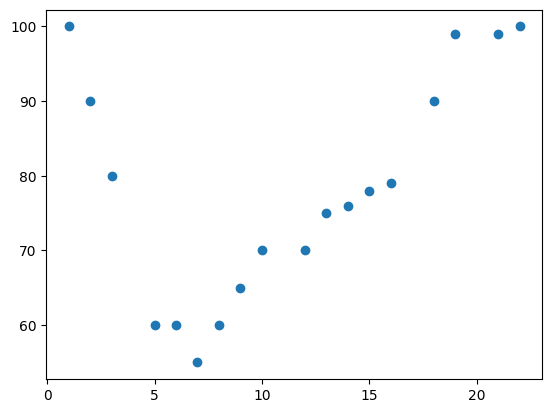

In [ ]:
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

plt.scatter(x, y)
plt.show()

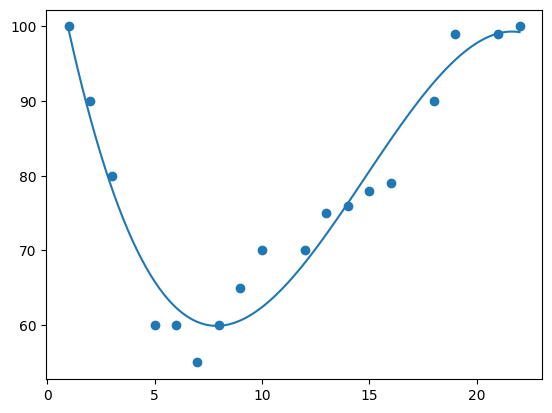

In [ ]:
mymodel = np.poly1d(np.polyfit(x, y, 3))
myline = np.linspace(1, 22, 100)

plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()

## R-squared

- Penting untuk diketahui seberapa baik hubungan antara nilai sumbu x dan y, jika tidak ada hubungan maka regresi polinomial tidak dapat digunakan untuk memprediksi apapun.
- Hubungan tersebut diukur dengan nilai yang disebut **r-squared**.
- Nilai **r-squared** berkisar dari 0 hingga 1, di mana 0 berarti tidak ada hubungan, dan 1 berarti 100% terkait.

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y, mymodel(x))
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = np.poly1d(np.polyfit(x, y, 3))
print(r2_score(y, mymodel(x)))

0.9432150416451026


In [ ]:
speed = mymodel(17)
print(speed)

88.87331269698001


## Regression Spline

- *Regression splines* adalah metode statistik yang digunakan untuk menangani hubungan non-linear antara variabel independen (prediktor) dan variabel dependen (respons).
- Dalam pendekatan ini, data dibagi menjadi beberapa segmen berdasarkan *knots* dan setiap segmen tersebut dimodelkan menggunakan
polinomial derajat rendah.
- Teknik ini sangat berguna karena memungkinkan fleksibilitas yang tinggi dalam memodelkan data tanpa risiko *overfitting* yang terjadi pada regresi polinomial derajat tinggi.

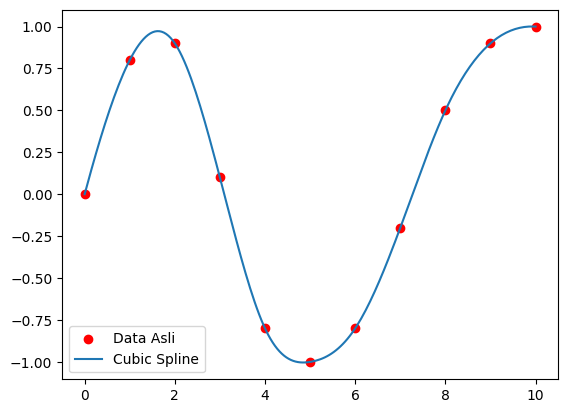

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. Data Sampel (Non-Linear)
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([0, 0.8, 0.9, 0.1, -0.8, -1, -0.8, -0.2, 0.5, 0.9, 1])

# 2. Membuat Spline (k=3 untuk Cubic Spline)
spline = make_interp_spline(x, y, k=3)

# 3. Menghasilkan poin halus untuk kurva
x_smooth = np.linspace(x.min(), x.max(), 200)
y_smooth = spline(x_smooth)

# 4. Plot Hasil
plt.scatter(x, y, color='red', label='Data Asli')
plt.plot(x_smooth, y_smooth, label='Cubic Spline')
plt.legend()
plt.show()

## Generalized Additive Models (GAM)

- *Generalized Additive Models (GAM)* adalah model regresi statistik yang memungkinkan relasi non-linear antara prediktor (variabel independen) dan respon (variabel dependen) dengan cara yang lebih fleksibel daripada model linier.

- GAM mengasumsikan bahwa hubungan antara prediktor dan respon dapat dipisahkan menjadi fungsi-fungsi terpisah dari setiap prediktor. Fungsi-fungsi ini kemudian digabungkan untuk membentuk model prediksi.

- GAM adalah perluasan dari regresi linier dengan setiap fungsi dari prediktor tidak harus linier.

- Model GAM secara matematis dapat ditulis sebagai:

   **Y = β0 + f1(X1) + f2(X2) + ... + fp(Xp) + ε**

   keterangan:

   f1, f2, ..., fp adalah fungsi nonparametrik yang menghubungkan setiap prediktor Xi dengan Y.
   
   GAM dapat digunakan dengan splines.

**Contoh Implementasi**

- Pastikan telah menginstal pyGAM, numpy, pandas, dan matplotlib.
- Contoh menggunakan data sintetis di mana variabel target memiliki hubungan nonlinear (sinusoidal) dengan fitur tunggal.

In [ ]:
pip install pygam numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, f

# Langkah 3: Siapkan data (contoh data sintetis)
np.random.seed(0)
X = np.random.rand(100, 1) * 10 # 100 data poin, 1 fitur
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 100) # variabel target dengan noise

# Langkah 4: Tentukan dan latih model GAM
# s(0) menentukan fungsi smoothing (smooth function) untuk fitur pertama (indeks 0)
gam = LinearGAM(s(0))
gam.fit(X, y)

# Langkah 5: Evaluasi model dan visualisasi
# Prediksi pada data baru untuk plotting
X_pred = np.linspace(0, 10, 500).reshape(-1, 1)
y_pred = gam.predict(X_pred)

In [ ]:
# Plot hasilnya
plt.figure(figsize=(10, 6))
plt.scatter(X.ravel(), y, alpha=0.5, label='Data Aktual')
plt.plot(X_pred.ravel(), y_pred, color='red', linewidth=2, label='GAM
Fit')
plt.title('Generalized Additive Model Fit (menggunakan pyGAM)')
plt.xlabel('Fitur X')
plt.ylabel('Variabel Target y')
plt.legend()
plt.show()

# Plot ketergantungan parsial (partial dependence plot)
# Ini menunjukkan kontribusi fungsi smoothing untuk fitur tersebut
plt.figure(figsize=(10, 6))

In [ ]:
# gam.partial_dependence dapat digunakan untuk memvisualisasikan efek setiap fitur secara terpisah
for i, term in enumerate(gam.terms):
  if term.is_smoothing_term:
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=0.95) #Menghitung interval kepercayaan 95%
    plt.plot(XX[:, i], pdep, label=f'Smooth term {i}')
    plt.fill_between(XX[:, i], confi[0], confi[1], alpha=0.2, label=f'95% CI term {i}')
    plt.scatter(X[:, i], np.repeat(0, X.shape[0]), marker='|',
             color='gray') # Menunjukkan distribusi data

plt.title('Partial Dependence Plot untuk Fitur 0')
plt.xlabel('Fitur X')
plt.ylabel('Partial Dependence')
plt.legend()
plt.show()